# Forecasting Models — Casual-Dining Restaurant Daily Sales

⚠️ **All data in this notebook is SIMULATED.** It was generated by `src/simulate_restaurant_sales.py`
to mimic order-of-magnitude sales patterns recalled from personal experience working in casual
dining (day-of-week effects, seasonality, weather sensitivity, promo days). No real point-of-sale,
financial, or transaction data is used anywhere in this project, and the restaurant is intentionally
unnamed — referred to only as "a casual-dining restaurant."

Two approaches are compared on a **time-based holdout** (no shuffling, since this is sequential daily data): **SARIMA** (classical, weekly-seasonal statistical model) vs. **XGBoost with lag/rolling features** (gradient-boosted trees on engineered time-series features).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

df = pd.read_csv('../data/daily_sales.csv', parse_dates=['date']).set_index('date').asfreq('D')
df.shape

(940, 18)

## Cleaning for modeling

Closures (Dec 25) are a known true zero, not missing data, so they're set explicitly. Simulated POS-outage gaps and partial-field gaps are interpolated — acceptable for a handful of isolated days, but flagged here rather than silently done.

In [2]:
n_missing_before = df['sales'].isna().sum()
df['sales_clean'] = df['sales']
df.loc[df['is_closed'] == True, 'sales_clean'] = 0
df['sales_clean'] = df['sales_clean'].interpolate(limit_direction='both')
print(f'Interpolated {n_missing_before} missing sales values (POS-outage days); '
      f'{int(df["is_closed"].sum())} closures set to 0.')

Interpolated 7 missing sales values (POS-outage days); 3 closures set to 0.


## Feature engineering (for XGBoost)

Lag and rolling-mean features, plus calendar/weather/event flags already present in the simulated dataset.

In [3]:
model_df = df[['sales_clean','is_weekend','is_special_day','month','weather']].copy()
model_df = model_df.rename(columns={'sales_clean': 'sales'})

for lag in [1, 7, 14, 28]:
    model_df[f'lag_{lag}'] = model_df['sales'].shift(lag)
model_df['roll_mean_7'] = model_df['sales'].shift(1).rolling(7).mean()
model_df['roll_mean_28'] = model_df['sales'].shift(1).rolling(28).mean()
model_df['dow'] = model_df.index.dayofweek
model_df = pd.get_dummies(model_df, columns=['weather'], drop_first=True)
model_df = model_df.dropna()
model_df.shape

(912, 14)

## Time-based train/test split

Last 90 days held out as the test period — no shuffling, so the split respects the sequential nature of the data.

In [4]:
split_date = model_df.index.max() - pd.Timedelta(days=90)
train = model_df[model_df.index <= split_date]
test = model_df[model_df.index > split_date]

print('Train:', train.index.min().date(), '->', train.index.max().date(), f'({len(train)} days)')
print('Test: ', test.index.min().date(), '->', test.index.max().date(), f'({len(test)} days)')

Train: 2024-01-20 -> 2026-04-20 (822 days)
Test:  2026-04-21 -> 2026-07-19 (90 days)


## Model 1: SARIMA

Order `(1,1,1)` with weekly seasonal order `(1,1,1,7)` — captures the dominant day-of-week cycle. A full annual seasonal term (period=365) is computationally impractical for a state-space SARIMA on daily data, so the slower seasonal cycle is a known blind spot for this model, discussed below.

In [5]:
sarima_train = df.loc[train.index, 'sales_clean']
sarima_test = df.loc[test.index, 'sales_clean']

sarima_model = SARIMAX(
    sarima_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False, enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.get_forecast(steps=len(sarima_test)).predicted_mean
sarima_pred.index = sarima_test.index
sarima_pred.head()

date
2026-04-21     4269.874607
2026-04-22     4457.993740
2026-04-23     4813.936532
2026-04-24     4913.810653
2026-04-25    10241.642139
Freq: D, Name: predicted_mean, dtype: float64

## Model 2: XGBoost (lag features)

In [6]:
feature_cols = [c for c in train.columns if c != 'sales']
X_train, y_train = train[feature_cols], train['sales']
X_test, y_test = test[feature_cols], test['sales']

xgb_model = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
xgb_model.fit(X_train, y_train)
xgb_pred = pd.Series(xgb_model.predict(X_test), index=X_test.index)
xgb_pred.head()

date
2026-04-21     5203.147949
2026-04-22     5280.154785
2026-04-23     5105.761719
2026-04-24     4720.835938
2026-04-25    11057.864258
Freq: D, dtype: float32

## Evaluation on holdout

In [7]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'{name:10s}  MAE=${mae:,.0f}   MAPE={mape:.1%}')
    return mae, mape

sarima_mae, sarima_mape = evaluate(sarima_test, sarima_pred, 'SARIMA')
xgb_mae, xgb_mape = evaluate(y_test, xgb_pred, 'XGBoost')

results = pd.DataFrame({
    'Model': ['SARIMA', 'XGBoost'],
    'MAE ($)': [round(sarima_mae), round(xgb_mae)],
    'MAPE': [f'{sarima_mape:.1%}', f'{xgb_mape:.1%}'],
}).set_index('Model')
results

SARIMA      MAE=$1,445   MAPE=14.4%
XGBoost     MAE=$959   MAPE=11.7%


,MAE ($),MAPE
Model,,
SARIMA,1445,14.4%
XGBoost,959,11.7%


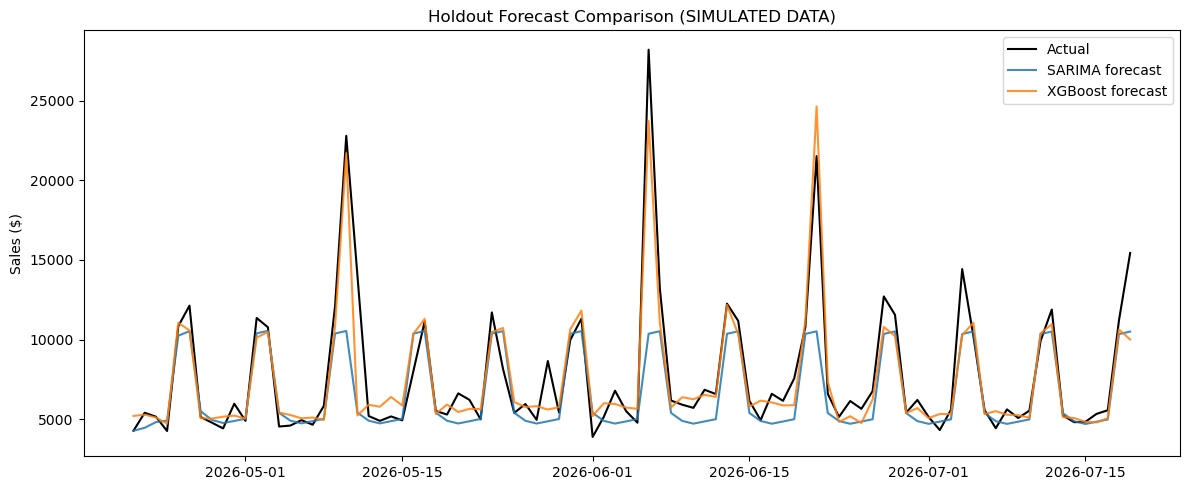

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(sarima_test.index, sarima_test.values, label='Actual', color='black', linewidth=1.5)
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA forecast', alpha=0.85)
plt.plot(xgb_pred.index, xgb_pred.values, label='XGBoost forecast', alpha=0.85)
plt.title('Holdout Forecast Comparison (SIMULATED DATA)')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

| Model | MAE | MAPE |
|---|---|---|
| SARIMA (weekly-seasonal) | $1,445 | 14.4% |
| XGBoost (lag/rolling features) | $959 | 11.7% |

**XGBoost wins** on this holdout, with ~34% lower MAE and ~3 points lower MAPE than SARIMA.

Why: XGBoost has direct access to engineered signals SARIMA can't easily use — the `is_weekend`,
`is_special_day`, `month`, and `weather` flags, plus 7/14/28-day lag and rolling-mean features
that approximate longer seasonal cycles. SARIMA's weekly seasonal term captures the day-of-week
effect well, but with only a `(1,1,1,7)` order it has no direct way to see the October peak /
summer trough or one-off special-day spikes — it can only infer them indirectly through
differencing and trend, which shows up as larger errors around those events. A full annual
seasonal SARIMA term (period=365) would address this but is computationally impractical for
daily data at this scale.

**Caveat:** this comparison is on simulated data with effect sizes the author chose, so the
absolute MAE/MAPE numbers are illustrative of methodology, not a claim about real-world
forecast accuracy for any actual restaurant.
